## Analysis of the datasets

#### Questions

Reason for food selection

Assumption:
The MASTER project likely selected foods to represent the broad microbial diversity present across the human food system. The chosen foods were probably guided by their relevance to human consumption and microbiome transfer, their technical suitability for metagenomic analysis (i.e., reliable DNA extraction and sequencing), and their diversity in composition and processing — including raw, fermented, plant-based, animal-based, and processed products. This strategic selection would enable a comprehensive exploration of how different food matrices contribute to microbial diversity, food safety, and potential links with the human microbiome.

data format is: tsv (tab-separated text tables)

Normalization has not been done as far as I'm concerned

In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


In [4]:
df_dataset = pd.read_csv('/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/cFMD/cFMD_datasets.tsv', sep='\t')

In [ ]:
df_dataset

,Dataset,# Samples,Accession number,Version,Reference
0,AlvarezOrdonezA_xxxx,173,"PRJNA997800, PRJNA997801",cFMDv1.0.0,*
1,ArikanM_2020,12,PRJEB22200,cFMDv1.0.0,"Arıkan, M., Mitchell, A.L., Finn, R.D., and Gü..."
2,BertuzziAS_2018,42,PRJEB15423,cFMDv1.0.0,"Bertuzzi, A.S., Walsh, A.M., Sheehan, J.J., Co..."
3,ChaconVargasK_2020,5,PRJNA603591,cFMDv1.0.0,"Chacón-Vargas, K., Torres, J., Giles-Gómez, M...."
4,CM_INJERA,2,PRJNA504891,cFMDv1.0.0,"Manara, S., Selma-Royo, M., Huang, K.D., Asnic..."
...,...,...,...,...,...
80,YangC_2021,8,PRJNA683931,cFMDv1.2.1,"Yang, Chengcong, Lijun You, Lai-Yu Kwok, Hao J..."
81,YapM_2020,18,PRJEB38099,cFMDv1.2.1,"Yap, Min, Conor Feehily, Calum J Walsh, Mark F..."
82,YasirM_2022,18,PRJNA816670,cFMDv1.2.1,"Yasir, Muhammad, Ibrahim A Al-Zahrani, Fehmida..."
83,YouL_2022,23,PRJNA687995,cFMDv1.2.1,"You, Lijun, Chengcong Yang, Hao Jin, Lai-Yu Kw..."


In [ ]:
df_dataset.info()

### Summary of the dataset included in the current release, with reference to the publication

----

## Description of the syntactic rules to define the metadata fields of the metadata

In [ ]:
df_metadata_rules = pd.read_csv('/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/cFMD/cFMD/cFMD_metadata_rules.tsv' , sep='\t' )

In [ ]:
df_metadata_rules

,col_name,uniqueness,requiredness,multiplevalues,allowedvalues,description
0,dataset_name,non-unique,required,False,[a-zA-Z-]+_[0-9]{4}[a-zA-Z_]*,Dataset name.
1,sample_id,unique,required,False,[0-9a-zA-Z]\S+,Sample identifier.
2,macrocategory,non-unique,required,False,Food,Categorical variable describing sample - highe...
3,category,non-unique,required,False,alcohol|dairy|fermented_beverages|fermented_fi...,Categorical variable describing sample - high ...
4,type,non-unique,required,False,[a-zA-Z]\S+,Categorical variable describing sample - low o...
5,subtype,non-unique,optional,False,[a-zA-Z]\S+,Categorical variable describing sample - lowes...
6,commercial_name,non-unique,optional,False,[a-zA-Z]\S+,Commercial name of the sample - if available o...
7,fermented/non-fermented,non-unique,required,False,F|NF,Dichotomous variable indicating Fermented or N...
8,country,non-unique,optional,False,ALA|AUS|AUT|BEL|BEN|BFA|BGR|CAN|CHE|CHN|COL|DE...,Country of acquisition using ISO3 code from ht...
9,sample_accession,non-unique,optional,False,[0-9a-zA-Z]\S+,Database code describing the biological sample.


In [ ]:
df_metadata_rules.info()

-----

### Mags (Metagenome-Assembled Genomes)
#### MAG information: origin, taxonomy (species-level genome bin = SGB), known/unknown SGB status, BUSCO-based taxonomy for eukaryotes, and genome quality stats (contigs, N50, completeness, contamination).

In [ ]:
df_Mags = pd.read_csv ('/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/cFMD/cFMD/cFMD_mags_list.tsv', sep='\t')

In [ ]:
df_Mags

,MAG_id,dataset_id,sample_id,SGB_id,assigned_taxonomy_level,superkingdom,phylum,class,order,family,genus,species,genome_size,n_contigs,N50,completeness,contamination,GC_content,BUSCO_taxonomy
0,AlvarezOrdonezA_xxxx__C02-16__bin.18,AlvarezOrdonezA_xxxx,C02-16,SGB31329,Species,Bacteria,Proteobacteria,Gammaproteobacteria,Moraxellales,Moraxellaceae,Acinetobacter,Acinetobacter_harbinensis,1657020.0,222.0,9302.0,65.423679,0.527190,0.414674,NaN
1,AlvarezOrdonezA_xxxx__C02-16__bin.19,AlvarezOrdonezA_xxxx,C02-16,SGB7517,Species,Bacteria,Firmicutes,Bacilli,Bacillales,Listeriaceae,Brochothrix,Brochothrix_thermosphacta,2141729.0,287.0,9351.0,94.475138,1.906077,0.366776,NaN
2,AlvarezOrdonezA_xxxx__C02-17__bin.16,AlvarezOrdonezA_xxxx,C02-17,SGB7517,Species,Bacteria,Firmicutes,Bacilli,Bacillales,Listeriaceae,Brochothrix,Brochothrix_thermosphacta,2259590.0,397.0,7223.0,97.513812,4.526822,0.368791,NaN
3,AlvarezOrdonezA_xxxx__C02-17__bin.17,AlvarezOrdonezA_xxxx,C02-17,SGB31329,Species,Bacteria,Proteobacteria,Gammaproteobacteria,Moraxellales,Moraxellaceae,Acinetobacter,Acinetobacter_harbinensis,1668526.0,322.0,6353.0,71.460634,1.366601,0.426261,NaN
4,AlvarezOrdonezA_xxxx__C02-19__bin.1,AlvarezOrdonezA_xxxx,C02-19,SGB10238,Species,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Yersiniaceae,Ewingella,Ewingella_americana,3816144.0,712.0,6480.0,64.912281,0.000000,0.549496,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14060,YouL_2022__SRR13308540__bin.4,YouL_2022,SRR13308540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10155660.0,279.0,58560.0,94.300000,0.000000,0.400000,saccharomycetes_odb10
14061,YouL_2022__SRR13308541__bin.10,YouL_2022,SRR13308541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10487470.0,397.0,38973.0,96.500000,0.000000,0.400000,saccharomycetes_odb10
14062,YouL_2022__SRR13308541__bin.15,YouL_2022,SRR13308541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11455573.0,473.0,37394.0,91.400000,0.218818,0.400000,saccharomycetes_odb10
14063,YouL_2022__SRR13308542__bin.13,YouL_2022,SRR13308542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11665807.0,639.0,29798.0,91.000000,0.549451,0.400000,saccharomycetes_odb10


    - ~2,948 food samples with species calls
	•	1,205 distinct species columns
	•	A clear fermentation flag is available: fermented/non-fermented with counts ≈ F: 2,669 and NF: 279.

##### - MAG_id : name of the MAG formed by dataset_name__sample_id__bin.bin_number
##### - Dataset_id : Name of the Dataset from which MAG has ben reconstructed
##### - SGB_id: Identification number of the SGB
##### - genome_size: nucleotides in the genome
##### - completeness: percentage value of the estimated completeness of the genome as determined from the presence/absence of marker genes and the expected colocalization of these genes (CheckM)
##### - contamination: percentage value of the estimated contamination of genome as determined by the presence of multi-copy marker genes and the expected colocalization of these genes (CheckM)
##### - GC_content: percentage of G+C nucleotides with respect to genome length


In [ ]:
df_Mags.info()

----

### Metadata info, statistics about reconstructed MAGs at sample level. 
- categorization of the samples

In [2]:
df_metadata = pd.read_csv('/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/cFMD/cFMD_metadata.tsv', sep='\t')

In [3]:
df_metadata.columns

Index(['dataset_name', 'sample_id', 'macrocategory', 'category', 'type',
       'subtype', 'commercial_name', 'fermented/non-fermented', 'country',
       'sample_accession', 'run_accession', 'experiment_accession',
       'study_accession', 'project_accession', 'database_origin',
       'library_layout', 'sequencing_platform', 'DNA_extraction_kit',
       'collection_date', 'n_of_bases', 'n_of_reads', 'min_read_len',
       'median_read_len', 'mean_read_len', 'max_read_len', 'n_contigs',
       'n_MAGs_MQ_prok', 'n_MAGs_HQ_prok', 'n_MAGs_MQ_euk', 'n_MAGs_HQ_euk',
       'filtered', 'curator'],
      dtype='object')

In [4]:
df_metadata['n_MAGs_MQ_prok']

0       0
1       0
2       0
3       0
4       1
       ..
3305    5
3306    5
3307    6
3308    3
3309    4
Name: n_MAGs_MQ_prok, Length: 3310, dtype: int64

-  type has the most descriptive form 
- Sequencing_platform 
    - 	MiSeq = detailed, small-scale
	•	NextSeq = medium-scale, faster
	•	HiSeq = large-scale, high-output
- DNA_extraction_kit : how they isolated the DNA in the sample
        - Each kit is optimized for a specific sample type — use water kits for water, soil kits for soil, and food kits for food — otherwise you risk low yield or inhibition.

- Reads = raw data (short pieces)
- Assembled reads /contigs = combined, reconstructed sequences, fewer but longer

- n_contigs : number of contigs with length > 1000 bp
- n_MAGs_MQ_prok: # of prokaryotic MAGs with 50%<=completeness<90% and contamination <5% according to CheckM

In [5]:
# Basic counts
df_metadata['category'].value_counts()

category
dairy                              2162
fermented_beverages                 435
fermented_meat                      157
meat                                119
fish                                 93
fermented_grains                     83
fermented_seeds                      65
fermented_fruits_and_vegetables      52
alcohol                              48
fruits_and_vegetables                25
fermented_tubers_and_roots           24
fermented_legumes                    20
probiotics                           14
other                                 8
fermented_fish                        5
Name: count, dtype: int64

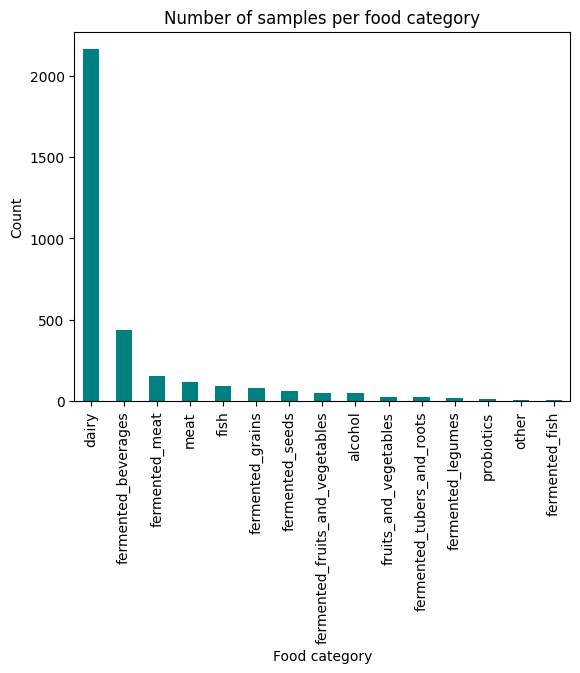

In [7]:
import matplotlib.pyplot as plt

df_metadata['category'].value_counts().plot(kind='bar', color='teal')
plt.title("Number of samples per food category")
plt.ylabel("Count")
plt.xlabel("Food category")
plt.show()

def not ballanced

In [8]:
# Basic counts
df_metadata['type'].value_counts()

type
cheese                 1508
water_kefir             388
kefir                   287
milk                    111
whey                     85
                       ... 
attieke                   1
boza                      1
carrot_sticks             1
tomato_and_mustards       1
tepache                   1
Name: count, Length: 118, dtype: int64

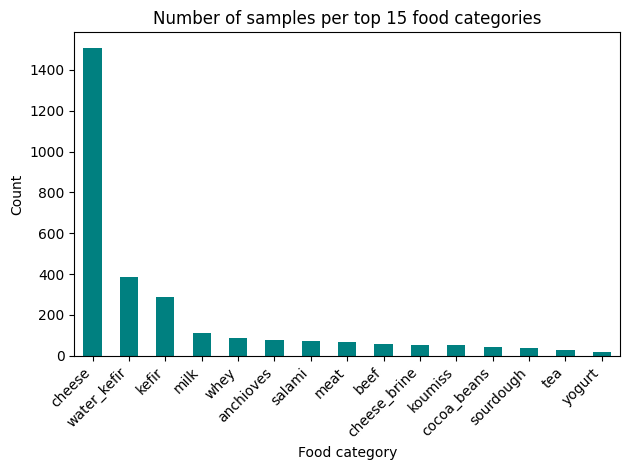

In [13]:
top15 = df_metadata['type'].value_counts().head(15)

top15.plot(kind='bar', color='teal')
plt.title("Number of samples per top 15 food categories")
plt.ylabel("Count")
plt.xlabel("Food category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

we see the most are the dairy and then meat. cheese def the most sampled

In [ ]:
df_metadata.info()

----

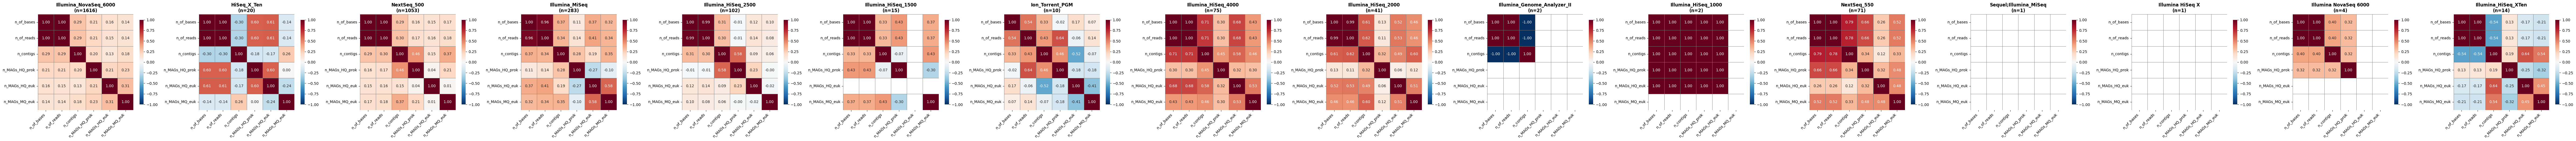


CORRELATION ANALYSIS SUMMARY

Illumina_NovaSeq_6000 (n=1616 samples)
----------------------------------------
  n_of_bases vs n_MAGs_HQ_prok: 0.209
  n_of_reads vs n_MAGs_HQ_prok: 0.206
  n_contigs vs n_MAGs_HQ_prok:  0.202

HiSeq_X_Ten (n=20 samples)
----------------------------------------
  n_of_bases vs n_MAGs_HQ_prok: 0.599
  n_of_reads vs n_MAGs_HQ_prok: 0.599
  n_contigs vs n_MAGs_HQ_prok:  -0.184

NextSeq_500 (n=1053 samples)
----------------------------------------
  n_of_bases vs n_MAGs_HQ_prok: 0.160
  n_of_reads vs n_MAGs_HQ_prok: 0.168
  n_contigs vs n_MAGs_HQ_prok:  0.459

Illumina_MiSeq (n=283 samples)
----------------------------------------
  n_of_bases vs n_MAGs_HQ_prok: 0.107
  n_of_reads vs n_MAGs_HQ_prok: 0.143
  n_contigs vs n_MAGs_HQ_prok:  0.283

Illumina_HiSeq_2500 (n=102 samples)
----------------------------------------
  n_of_bases vs n_MAGs_HQ_prok: -0.010
  n_of_reads vs n_MAGs_HQ_prok: -0.009
  n_contigs vs n_MAGs_HQ_prok:  0.580

Illumina_HiSeq_1500 (n=1

In [10]:
# Define columns for correlation analysis
seq_cols = ['n_of_bases', 'n_of_reads', 'n_contigs']
mag_cols = ['n_MAGs_HQ_prok', 'n_MAGs_HQ_euk', 'n_MAGs_MQ_euk']
all_cols = seq_cols + mag_cols

# Get unique platforms
platforms = df_metadata['sequencing_platform'].unique()
n_platforms = len(platforms)

# Create figure with subplots
fig, axes = plt.subplots(1, n_platforms, figsize=(6*n_platforms, 5))
if n_platforms == 1:
    axes = [axes]

# Calculate and plot correlation for each platform
for idx, platform in enumerate(platforms):
    # Filter data for this platform
    df_platform = df_metadata[df_metadata['sequencing_platform'] == platform][all_cols]
    
    # Drop rows with any NaN values
    df_platform = df_platform.dropna()
    
    # Calculate Spearman correlation (robust to outliers)
    corr_matrix = df_platform.corr(method='spearman')
    
    # Create heatmap
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={'shrink': 0.8},
        ax=axes[idx],
        linewidths=0.5,
        linecolor='gray'
    )
    
    # Set title with sample count
    axes[idx].set_title(f'{platform}\n(n={len(df_platform)})', 
                        fontsize=12, fontweight='bold')
    
    # Rotate labels
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
    axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("CORRELATION ANALYSIS SUMMARY")
print("="*80)
for platform in platforms:
    df_platform = df_metadata[df_metadata['sequencing_platform'] == platform][all_cols].dropna()
    print(f"\n{platform} (n={len(df_platform)} samples)")
    print("-" * 40)
    
    # Key correlations to highlight
    if len(df_platform) > 2:
        corr = df_platform.corr(method='spearman')
        print(f"  n_of_bases vs n_MAGs_HQ_prok: {corr.loc['n_of_bases', 'n_MAGs_HQ_prok']:.3f}")
        print(f"  n_of_reads vs n_MAGs_HQ_prok: {corr.loc['n_of_reads', 'n_MAGs_HQ_prok']:.3f}")
        print(f"  n_contigs vs n_MAGs_HQ_prok:  {corr.loc['n_contigs', 'n_MAGs_HQ_prok']:.3f}")
    else:
        print("  Insufficient samples for correlation")